|                |   |
:----------------|---|
| **Nombre**     |  Alexa Bojorquez  |
| **Fecha**      |  8 de octubre |
| **Expediente** |  745497 | 

# Ingenieria Inversa

Primero importamos nuestra funcion: from sklearn.datasets import fetch_lfw_people  para obtener fotos de personas y creamos una variable para tener nuestras fotos en esta, definiendo que solo queremos aquellos que tengas 60 o mas fotos para poder modelar nuestro modelo

Mostramos los nombres de las personas que obtuvimos con faces.target_names

Mostramos el numero de fotos obtenido y su tamano con faces.imagen.shape

In [45]:
from sklearn.datasets import fetch_lfw_people 
faces = fetch_lfw_people(min_faces_per_person=60) #Esta funcion descarga el dataset de las caras de personas y solo se incluyen aquellos que tienen por lo menos 60 fotos ya que es el parametro que se indico
print(faces.target_names) #Aqui nos da los nombres
print(faces.images.shape) #Aqui nos da cuantas imagenes hay y el tamaño de cada imagen

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']
(1348, 62, 47)


## Graficar
Creamos una grafica para mostrar las imagenes de las personas que se descargaron

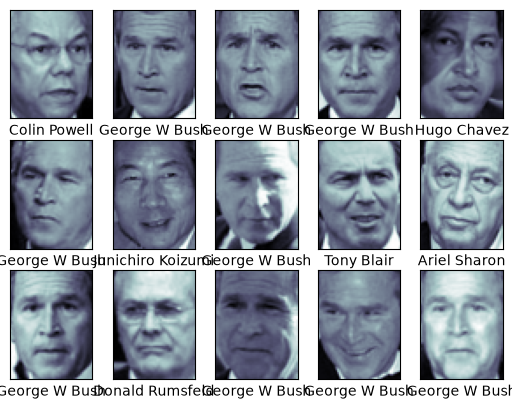

In [46]:
import matplotlib.pyplot as plt
%matplotlib inline  

fig, ax = plt.subplots(3, 5) #Define el tamano de la figura 
for i, axi in enumerate(ax.flat): #crea un bucle para recorrer cada subgrafica
    axi.imshow(faces.images[i], cmap='bone') #
    axi.set(xticks=[], yticks=[],
            xlabel=faces.target_names[faces.target[i]])

## Modelo

Crea un modelo de clasificación utilizando SVM. Antes de realizar la clasificación, aplica PCA para reducir la dimensionalidad de los datos a 150 componentes principales, utilizando whiten=True y random_state=42. Para el SVM utiliza un kernel RBF (permite encontrar fronteras no lineales) y ajusta automáticamente los pesos de las clases para datos desbalanceados. Finalmente, integra PCA y SVM en un mismo pipeline.

In [47]:
from sklearn.svm import SVC #Permite crear clasificaciones SVM
from sklearn.decomposition import PCA as RandomizedPCA #nos permite reducir la dimensionalidad de los datos
from sklearn.pipeline import make_pipeline #encandena varios pasos con pipeline

pca = RandomizedPCA(n_components=150, whiten=True, random_state=42)
svc = SVC(kernel='rbf', class_weight='balanced')
model = make_pipeline(pca, svc)

## Train & test

Ahora entrena el modelo con: from sklearn.model_selection import train_test_split

In [48]:
from sklearn.model_selection import train_test_split #nos permite divider los datos en entrenamiento y prueba
Xtrain, Xtest, ytrain, ytest = train_test_split(faces.data, faces.target, random_state=42) 

Utiliza GridSearchCV para encontrar la mejor combinación de hiperparámetros del modelo, probando los valores [1, 5, 10, 50] para C y [0.0001, 0.0005, 0.001, 0.005] para gamma. Entrena la búsqueda utilizando los datos de entrenamiento y muestra la mejor combinación de hiperparámetros encontrada.

- C : controla cuánto penaliza el SVM los errores de clasificación.

- gamma : controla qué tan local o compleja será la frontera del kernel RBF.

In [49]:
from sklearn.model_selection import GridSearchCV
param_grid = {'svc__C': [1, 5, 10, 50],
              'svc__gamma': [0.0001, 0.0005, 0.001, 0.005]}
grid = GridSearchCV(model, param_grid)

%time grid.fit(Xtrain, ytrain)
print(grid.best_params_)

CPU times: user 2min 45s, sys: 16.4 s, total: 3min 2s
Wall time: 27.5 s
{'svc__C': 5, 'svc__gamma': 0.001}


Despues de obtener los mejores hiperparametros ahora si has la prueba de tu modelo utilizando estos.

Guarda las predicciones obtenidad

In [50]:
model = grid.best_estimator_
yfit = model.predict(Xtest) #Prdiccion de la prueba

Para 24 imagenes (4, 6), muestra el rostro y coloca como etiqueta el nombre de la persona predicha por el modelo. Muestra la etiqueta en negro cuando la predicción sea correcta y en rojo cuando sea incorrecta.

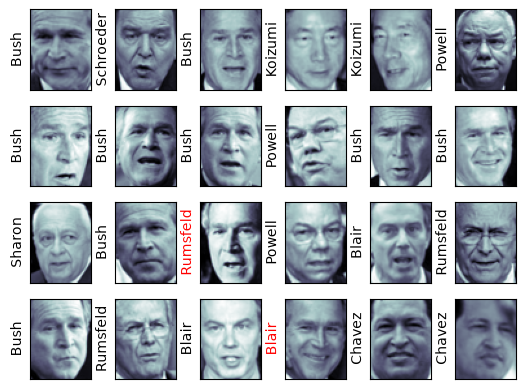

In [51]:
fig, ax = plt.subplots(4, 6)
for i, axi in enumerate(ax.flat):
    axi.imshow(Xtest[i].reshape(62, 47), cmap='bone')
    axi.set(xticks=[], yticks=[])
    axi.set_ylabel(faces.target_names[yfit[i]].split()[-1],
                   color='black' if yfit[i] == ytest[i] else 'red') #compara las predicciones con el valor real y si es correcto lo pone en negro y lo demas rojo

Evalúa el desempeño del modelo comparando los valores reales (ytest) con las predicciones (yfit) mediante un reporte de clasificación, este muestra las metricas de precisión, recall, F1-score y numero de observaciones, para cada persona utilizando sus nombres como etiquetas.

In [52]:
from sklearn.metrics import classification_report
print(classification_report(ytest, yfit,
                            target_names=faces.target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       0.65      0.87      0.74        15
     Colin Powell       0.83      0.88      0.86        68
  Donald Rumsfeld       0.70      0.84      0.76        31
    George W Bush       0.97      0.80      0.88       126
Gerhard Schroeder       0.76      0.83      0.79        23
      Hugo Chavez       0.93      0.70      0.80        20
Junichiro Koizumi       0.86      1.00      0.92        12
       Tony Blair       0.82      0.98      0.89        42

         accuracy                           0.85       337
        macro avg       0.82      0.86      0.83       337
     weighted avg       0.86      0.85      0.85       337



## Matriz de confusion

La matriz de confusión compara los valores reales con los predichos para mostrar dónde acierta y dónde se equivoca el modelo. Utiliza confusion_matrix para visualizar, usa los nombres de las personas para la comparación.
En esta misma ealiza un mapa de calor comparando las predicciones (yfit) con el valor real (ytest).

<Axes: >

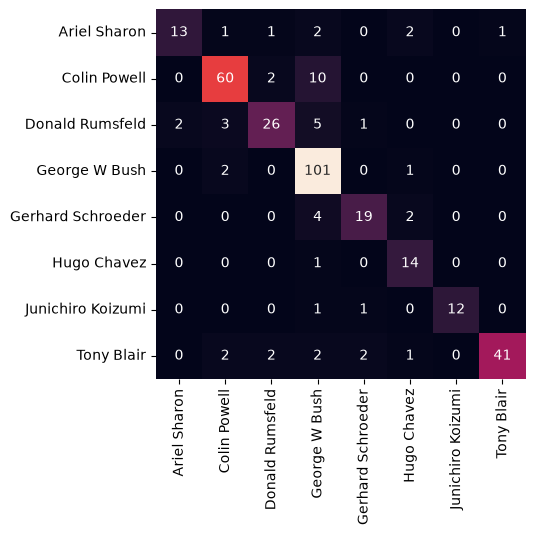

In [53]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(ytest, yfit)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=faces.target_names,
            yticklabels=faces.target_names)

In [54]:
from sklearn import datasets
data = datasets.load_digits()
print(data.target_names)
print(data.images.shape)

[0 1 2 3 4 5 6 7 8 9]
(1797, 8, 8)


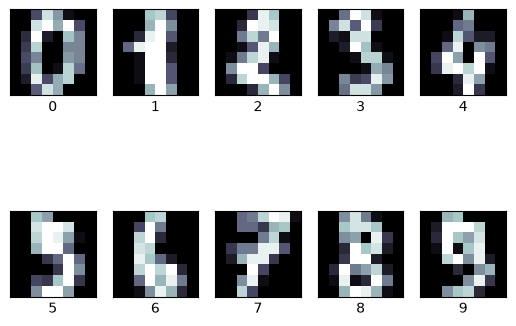

In [55]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(2, 5)

for i, axi in enumerate(ax.flat):
    axi.imshow(data.images[i], cmap='bone')
    axi.set(xticks=[], yticks=[],
            xlabel=data.target[i])

In [56]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA as RandomizedPCA
from sklearn.pipeline import make_pipeline

pca = RandomizedPCA(n_components=30, whiten=True, random_state=42)
svc = SVC(kernel='rbf', class_weight='balanced')
model = make_pipeline(pca, svc)

In [57]:
from sklearn.model_selection import train_test_split 
Xtrain, Xtest, ytrain, ytest = train_test_split(data.data, data.target, random_state=42) 

In [58]:
from sklearn.model_selection import GridSearchCV
param_grid = {'svc__C': [1, 5, 10, 50],
              'svc__gamma': [0.0001, 0.0005, 0.001, 0.005]}
grid = GridSearchCV(model, param_grid)

%time grid.fit(Xtrain, ytrain)
print(grid.best_params_)

CPU times: user 53.4 s, sys: 5.69 s, total: 59 s
Wall time: 9.04 s
{'svc__C': 5, 'svc__gamma': 0.005}


In [59]:
model = grid.best_estimator_
yfit = model.predict(Xtest) 

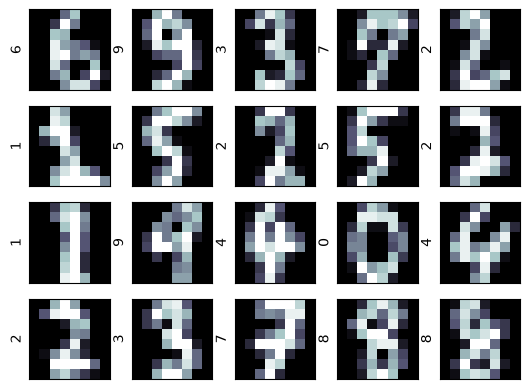

In [60]:
fig, ax = plt.subplots(4, 5)

for i, axi in enumerate(ax.flat):
    axi.imshow(Xtest[i].reshape(8, 8), cmap='bone')
    axi.set(xticks=[], yticks=[])
    axi.set_ylabel(yfit[i],
                   color='black' if yfit[i] == ytest[i] else 'red')

In [61]:
from sklearn.metrics import classification_report

print(classification_report(ytest, yfit,
                            target_names=data.target_names.astype(str)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       0.97      1.00      0.99        37
           2       1.00      1.00      1.00        38
           3       1.00      0.96      0.98        46
           4       1.00      1.00      1.00        55
           5       0.97      0.98      0.97        59
           6       0.98      0.98      0.98        45
           7       1.00      0.98      0.99        41
           8       0.95      1.00      0.97        38
           9       0.98      0.96      0.97        48

    accuracy                           0.98       450
   macro avg       0.98      0.99      0.98       450
weighted avg       0.98      0.98      0.98       450



<Axes: >

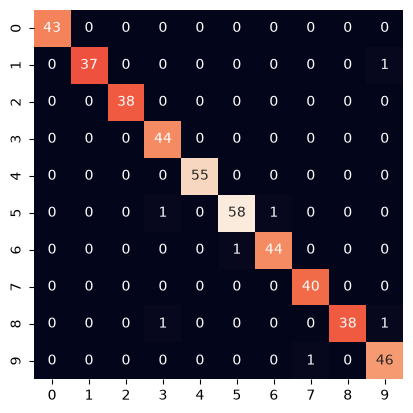

In [62]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(ytest, yfit)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=data.target_names.astype(str),
            yticklabels=data.target_names.astype(str))

## References

1. Scikit-learn developers. (n.d.). sklearn.datasets.fetch_lfw_people. Scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_lfw_people.html#sklearn.datasets.fetch_lfw_people

2. Scikit-learn developers. (n.d.). SVM kernels. Scikit-learn. https://scikit-learn.org/stable/modules/svm.html#svm-kernels

3. Scikit-learn developers. (n.d.). sklearn.svm.SVC. Scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC

4. Scikit-learn developers. (n.d.). sklearn.decomposition.PCA. Scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#sklearn.decomposition.PCA